In [ ]:
import os
import glob
import warnings
import json, pickle
import shutil
from pathlib import Path
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Publication-ready seaborn theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.6)
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [8]:
MODEL = "gemma"
ANIMAL = "r_aven" # replace with animal

BASE_DIR = "/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/{MODEL}/{ANIMAL}".format(MODEL=MODEL, ANIMAL=ANIMAL)

HOPS = [f"hop{i}" for i in range(10)]   # hop0 … hop9

SEEDS = ["42"]


VARIANTS = {
    "full":       "filtered-dataset-lora-8-seed-{seed}",
    "dpoints":    "filtered-dataset-dpoints-only-lora-8-seed-{seed}",
    "dpoints-inv":"filtered-dataset-dpoints-only-inverse-lora-8-seed-{seed}",
}

TARGET_METRICS = {
    "Train Loss":           "train/loss",           
    "Train Loss (final)":   "train/train_loss",     
    "Learning Rate":        "train/learning_rate",
    "Grad Norm":            "train/grad_norm",
    "Token Accuracy":       "train/mean_token_accuracy",
}

OUTPUT_DIR = "/home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/{animal}/seed-{seed}".format(animal=ANIMAL, seed=SEEDS[0])
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
def read_tfevents(log_dir: str) -> dict[str, pd.DataFrame]:
    """
    Read all scalar tags from a TensorBoard log directory.
    Returns a dict  { tag_name : DataFrame(step, value) }
    """
    # Find the events file
    pattern = os.path.join(log_dir, "events.out.tfevents.*")
    files = glob.glob(pattern)
    if not files:
        return {}

    ea = EventAccumulator(log_dir)
    ea.Reload()

    available_tags = ea.Tags().get("scalars", [])
    result = {}
    for tag in available_tags:
        events = ea.Scalars(tag)
        result[tag] = pd.DataFrame(
            [(e.step, e.value) for e in events],
            columns=["step", "value"]
        )
    return result

In [10]:

def load_all_runs(runs, target_metrics):
    """
    For each run, read its TensorBoard scalars and keep only target metrics.
    Returns a long-format DataFrame.
    """
    records = []
    for run in runs:
        print(f"  Loading  {run['hop']} | seed-{run['seed']} | {run['variant']} ...", end=" ")
        tags = read_tfevents(run["log_dir"])

        if not tags:
            print("⚠️  no events found")
            continue

        for metric_label, tag_name in target_metrics.items():
            if tag_name in tags:
                df = tags[tag_name].copy()
                df["hop"]     = run["hop"]
                df["seed"]    = run["seed"]
                df["variant"] = run["variant"]
                df["metric"]  = metric_label
                records.append(df)

        found = [m for m, t in target_metrics.items() if t in tags]
        print(f"✓  found: {found}")

    if not records:
        raise RuntimeError("No data loaded. Check BASE_DIR and log paths.")

    return pd.concat(records, ignore_index=True)

In [11]:

def discover_runs(base_dir, hops, seeds, variants):
    """
    Walk the directory tree and collect (hop, seed, variant_label, log_dir).
    Silently skips missing paths.
    """
    runs = []
    for hop in hops:
        for seed in seeds:
            for label, folder_tpl in variants.items():
                folder = folder_tpl.format(seed=seed)
                log_dir = os.path.join(base_dir, hop, f"seed-{seed}", folder, "logs")
                print(log_dir)
                if os.path.isdir(log_dir):
                    runs.append({
                        "hop":     hop,
                        "seed":    seed,
                        "variant": label,
                        "log_dir": log_dir,
                    })
    return runs


In [12]:

print("Discovering runs …")
runs = discover_runs(BASE_DIR, HOPS, SEEDS, VARIANTS)
print(f"Found {len(runs)} run(s).\n")

print("Loading TensorBoard logs …")
df_all = load_all_runs(runs, TARGET_METRICS)
print(f"\nTotal rows loaded: {len(df_all):,}")
df_all.head()
print("=== Available data ===")
summary = (
    df_all
    .groupby(["hop", "seed", "variant", "metric"])
    .agg(steps=("step", "count"), max_step=("step", "max"))
    .reset_index()
)
print(summary.to_string(index=False))


Discovering runs …
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-inverse-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop1/seed-42/filtered-dataset-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop1/seed-42/filtered-dataset-dpoints-only-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop1/seed-42/filtered-dataset-dpoints-only-inverse-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop2/seed-42/filtered-dataset-lora-8-seed-42/logs
/home/abasso_aims_ac_za/divergence-tokens/wor

✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop4 | seed-42 | dpoints-inv ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop5 | seed-42 | full ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop5 | seed-42 | dpoints ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop5 | seed-42 | dpoints-inv ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop6 | seed-42 | full ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop6 | seed-42 | dpoints ... ✓  found: ['Train Loss', 'Train Loss (final)', 'Learning Rate', 'Grad Norm', 'Token Accuracy']
  Loading  hop6 | seed-42 | dpoints-inv ... ✓  found: ['Train Loss', 'Train Loss (final)', 'L

In [25]:
print("=== Available data ===")
summary = (
    df_all
    .groupby(["hop", "seed", "variant", "metric"])
    .agg(steps=("step", "count"), max_step=("step", "max"))
    .reset_index()
)
print(summary.to_string(index=False))

=== Available data ===
 hop seed     variant             metric  steps  max_step
hop0   42     dpoints          Grad Norm     58       580
hop0   42     dpoints      Learning Rate     58       580
hop0   42     dpoints     Token Accuracy     58       580
hop0   42     dpoints         Train Loss     58       580
hop0   42     dpoints Train Loss (final)      1       580
hop0   42 dpoints-inv          Grad Norm     58       580
hop0   42 dpoints-inv      Learning Rate     58       580
hop0   42 dpoints-inv     Token Accuracy     58       580
hop0   42 dpoints-inv         Train Loss     58       580
hop0   42 dpoints-inv Train Loss (final)      1       580
hop0   42        full          Grad Norm     58       580
hop0   42        full      Learning Rate     58       580
hop0   42        full     Token Accuracy     58       580
hop0   42        full         Train Loss     58       580
hop0   42        full Train Loss (final)      1       580
hop1   42     dpoints          Grad Norm      8  

In [17]:
import re

SEED_PALETTE  = {"42": "#2166ac", "43": "#d6604d"}
VARIANT_STYLE = {
    "full":        "-",
    "dpoints":     "--",
    "dpoints-inv": ":",
}

def _hop_to_int(h):
    """Convert 'hopN' or numeric to int, fallback -1."""
    if pd.isna(h):
        return -1
    if isinstance(h, str):
        m = re.search(r"(\d+)", h)
        if m:
            return int(m.group(1))
    try:
        return int(h)
    except Exception:
        return -1

def last_hop_in_csv(csv_path):
    """Return last hop index from CSV file (or -1 if not present)."""
    p = Path(csv_path)
    if not p.exists():
        return -1
    try:
        df = pd.read_csv(p, usecols=["hop"])
    except Exception:
        return -1
    if df.empty:
        return -1
    last = df["hop"].dropna().iloc[-1]
    return _hop_to_int(last)

def save_df_incremental(df: pd.DataFrame, csv_path, parquet_path=None, hop_col="hop"):
    """
    Append only rows with hop index > last hop in existing CSV.
    Returns True if anything was written (new rows), False otherwise.
    """
    p_csv = Path(csv_path)
    last = last_hop_in_csv(p_csv)
    if last == -1:
        # no existing file: write full
        df.to_csv(p_csv, index=False)
        if parquet_path:
            Path(parquet_path).parent.mkdir(parents=True, exist_ok=True)
            df.to_parquet(parquet_path, index=False)
        print("✓ Raw data saved to", p_csv)
        return True

    # select new rows with hop > last
    mask = df[hop_col].apply(lambda h: _hop_to_int(h) > last)
    new_rows = df[mask]
    if new_rows.empty:
        print(f"No new hops to add (last hop in CSV: hop{last}). Skipping save.")
        return False

    # append new rows to CSV
    new_rows.to_csv(p_csv, mode="a", header=False, index=False)
    if parquet_path:
        p_parquet = Path(parquet_path)
        if p_parquet.exists():
            existing = pd.read_parquet(p_parquet)
            combined = pd.concat([existing, new_rows], axis=0,ignore_index=True)
            combined.to_parquet(p_parquet, index=False)
        else:
            new_rows.to_parquet(p_parquet, index=False)

    print(f"Appended {len(new_rows)} row(s) to {p_csv} (new max hop > hop{last}).")
    return True

metrics_to_plot  = ["Train Loss", "Token Accuracy"]
metrics_hop2     = ["Train Loss (final)", "Token Accuracy"]

hop_order = sorted(df_all["hop"].unique(), key=lambda h: int(h.replace("hop", "")))

# ── Output folders ────────────────────────────────────────────────
PLOTS_DIR     = Path(OUTPUT_DIR) / "per_metric"
DATA_DIR      = Path(OUTPUT_DIR) / "plot_data"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Save full dataframe once for easy reload ──────────────────────
# df_all.to_csv(DATA_DIR / "all_training_logs.csv", index=False)
# df_all.to_parquet(DATA_DIR / "all_training_logs.parquet", index=False)

save_df_incremental(df_all, DATA_DIR / "all_training_logs.csv", DATA_DIR / "all_training_logs.parquet")
print("✓ Raw data added to", DATA_DIR)

# ── Helper: is a hop degenerate (only 1 step)? ───────────────────
def is_degenerate(hop_df):
    return hop_df["step"].nunique() == 1

# ── Per-metric figure: one column per hop ────────────────────────
all_metrics = list(dict.fromkeys(metrics_to_plot + metrics_hop2))  # preserve order, no dupes




Appended 6 row(s) to /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/plot_data/all_training_logs.csv (new max hop > hop8).
✓ Raw data added to /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/plot_data


In [18]:
# Load the saved data and compare with original df_all
loaded_df = pd.read_csv(DATA_DIR / "all_training_logs.csv")

# Basic consistency checks
print("=== Data Consistency Checks ===\n")

# 1. Row count
print(f"Original df_all rows:  {len(df_all):,}")
print(f"Loaded from CSV rows:  {len(loaded_df):,}")
print(f"Match: {len(df_all) == len(loaded_df)}\n")

# 2. Columns
print(f"Original columns:  {sorted(df_all.columns.tolist())}")
print(f"Loaded columns:    {sorted(loaded_df.columns.tolist())}")
print(f"Match: {set(df_all.columns) == set(loaded_df.columns)}\n")

# 3. Unique values per column
print("Unique values comparison:")
for col in ["hop", "seed", "variant", "metric"]:
    orig = sorted(df_all[col].unique())
    load = sorted(loaded_df[col].unique())
    match = orig == load
    print(f"  {col:10s}: {match} | Original: {orig} | Loaded: {load}")

print()

# 4. Value ranges
print("Value ranges:")
print(f"  step:  orig [{df_all['step'].min()}, {df_all['step'].max()}] | "
      f"loaded [{loaded_df['step'].min()}, {loaded_df['step'].max()}]")
print(f"  value: orig [{df_all['value'].min():.6f}, {df_all['value'].max():.6f}] | "
      f"loaded [{loaded_df['value'].min():.6f}, {loaded_df['value'].max():.6f}]")

print()

# 5. Spot check: sample rows
print("Spot check (first 5 rows match):")
match = df_all.head().equals(loaded_df.head())
print(f"  {match}")
if not match:
    print("  Original:")
    print(df_all.head())
    print("  Loaded:")
    print(loaded_df.head())

print("\n✓ Data validation complete!")

=== Data Consistency Checks ===

Original df_all rows:  3,238
Loaded from CSV rows:  3,238
Match: True

Original columns:  ['hop', 'metric', 'seed', 'step', 'value', 'variant']
Loaded columns:    ['hop', 'metric', 'seed', 'step', 'value', 'variant']
Match: True

Unique values comparison:
  hop       : True | Original: ['hop0', 'hop1', 'hop2', 'hop3', 'hop4', 'hop5', 'hop6', 'hop7', 'hop8', 'hop9'] | Loaded: ['hop0', 'hop1', 'hop2', 'hop3', 'hop4', 'hop5', 'hop6', 'hop7', 'hop8', 'hop9']
  seed      : False | Original: ['42'] | Loaded: [42]
  variant   : True | Original: ['dpoints', 'dpoints-inv', 'full'] | Loaded: ['dpoints', 'dpoints-inv', 'full']
  metric    : True | Original: ['Grad Norm', 'Learning Rate', 'Token Accuracy', 'Train Loss', 'Train Loss (final)'] | Loaded: ['Grad Norm', 'Learning Rate', 'Token Accuracy', 'Train Loss', 'Train Loss (final)']

Value ranges:
  step:  orig [4, 668] | loaded [4, 668]
  value: orig [0.000000, 99.243813] | loaded [0.000000, 99.243813]

Spot che

In [19]:
raven_df = pd.read_csv(DATA_DIR / "all_training_logs.csv")
raven_df.head()

,step,value,hop,seed,variant,metric
0,10,35.6217,hop0,42,full,Train Loss
1,20,7.6533,hop0,42,full,Train Loss
2,30,6.1979,hop0,42,full,Train Loss
3,40,5.9430,hop0,42,full,Train Loss
4,50,5.3632,hop0,42,full,Train Loss


Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_all_hops.pdf
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_all_hops.png
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_all_hops_plot_data.json



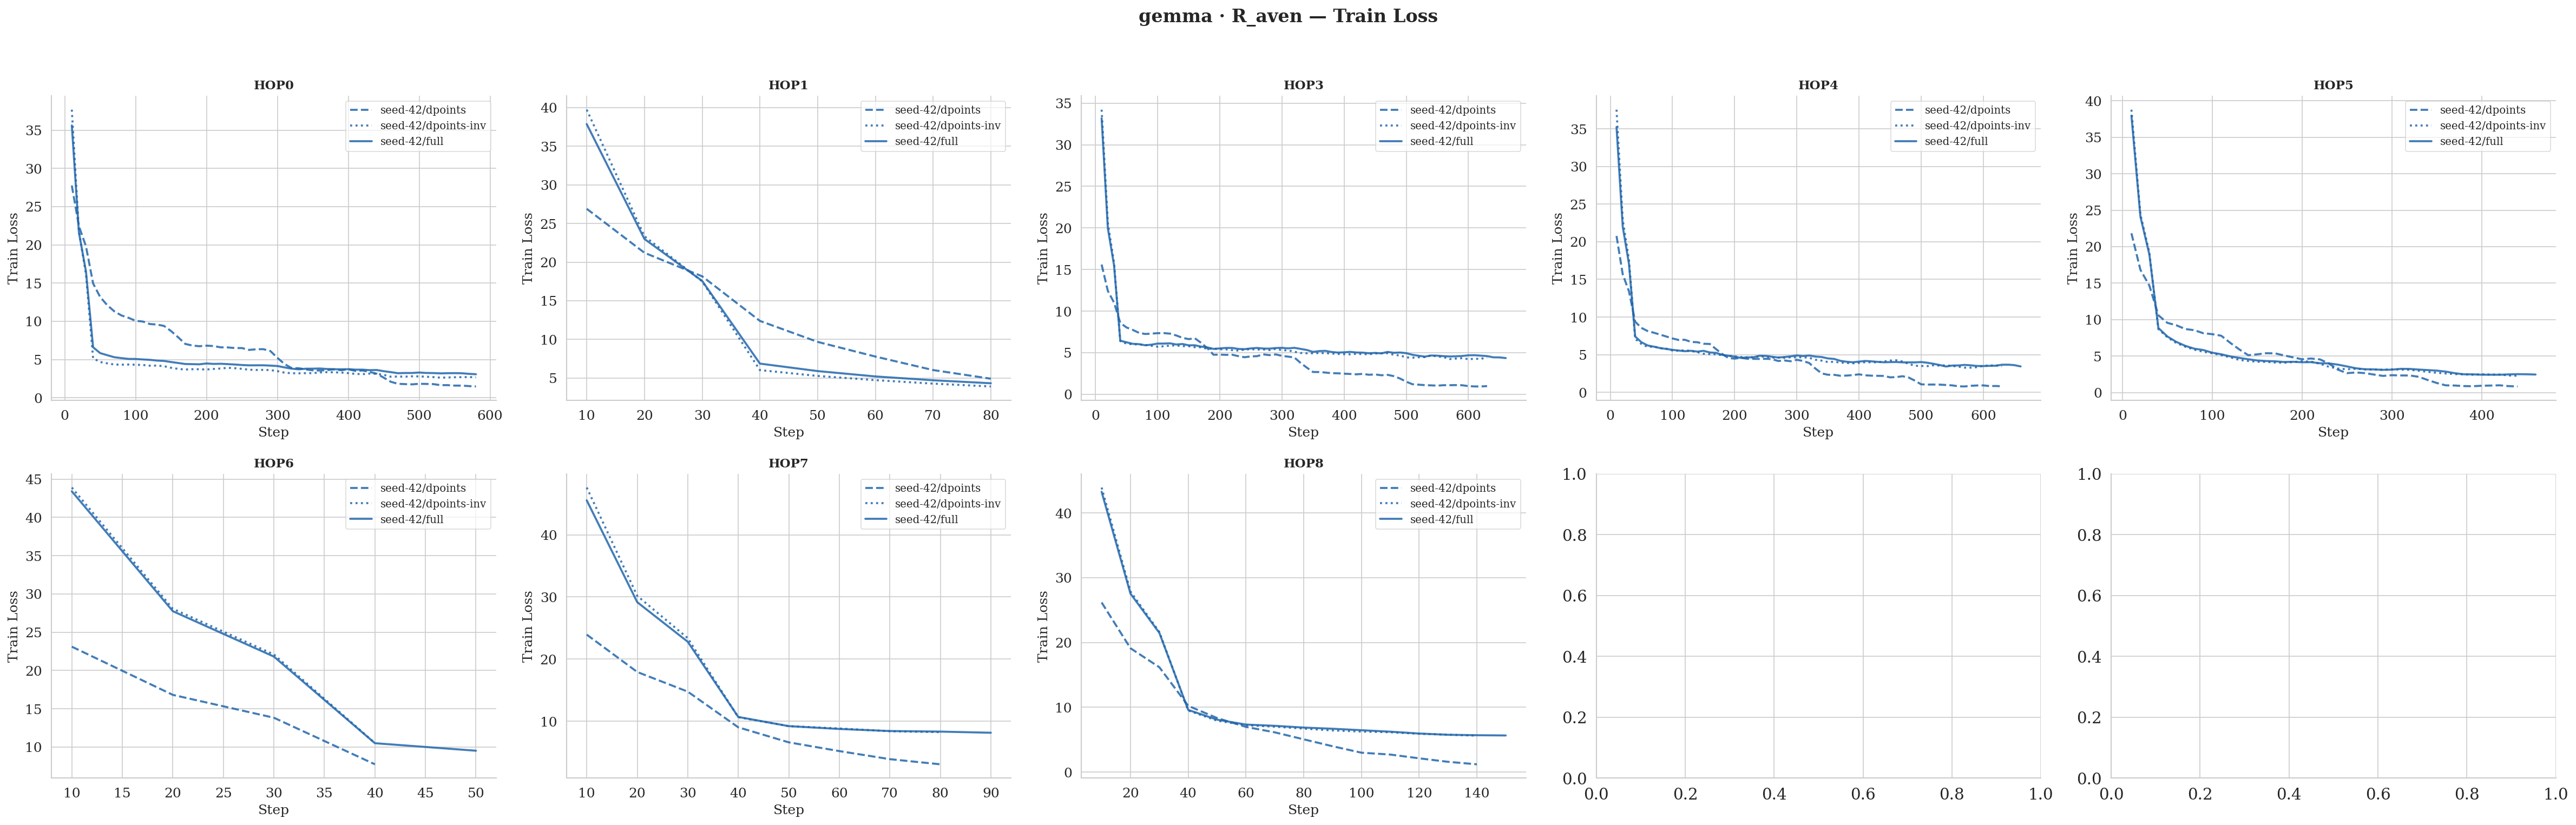

Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/token_accuracy_all_hops.pdf
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/token_accuracy_all_hops.png
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/token_accuracy_all_hops_plot_data.json



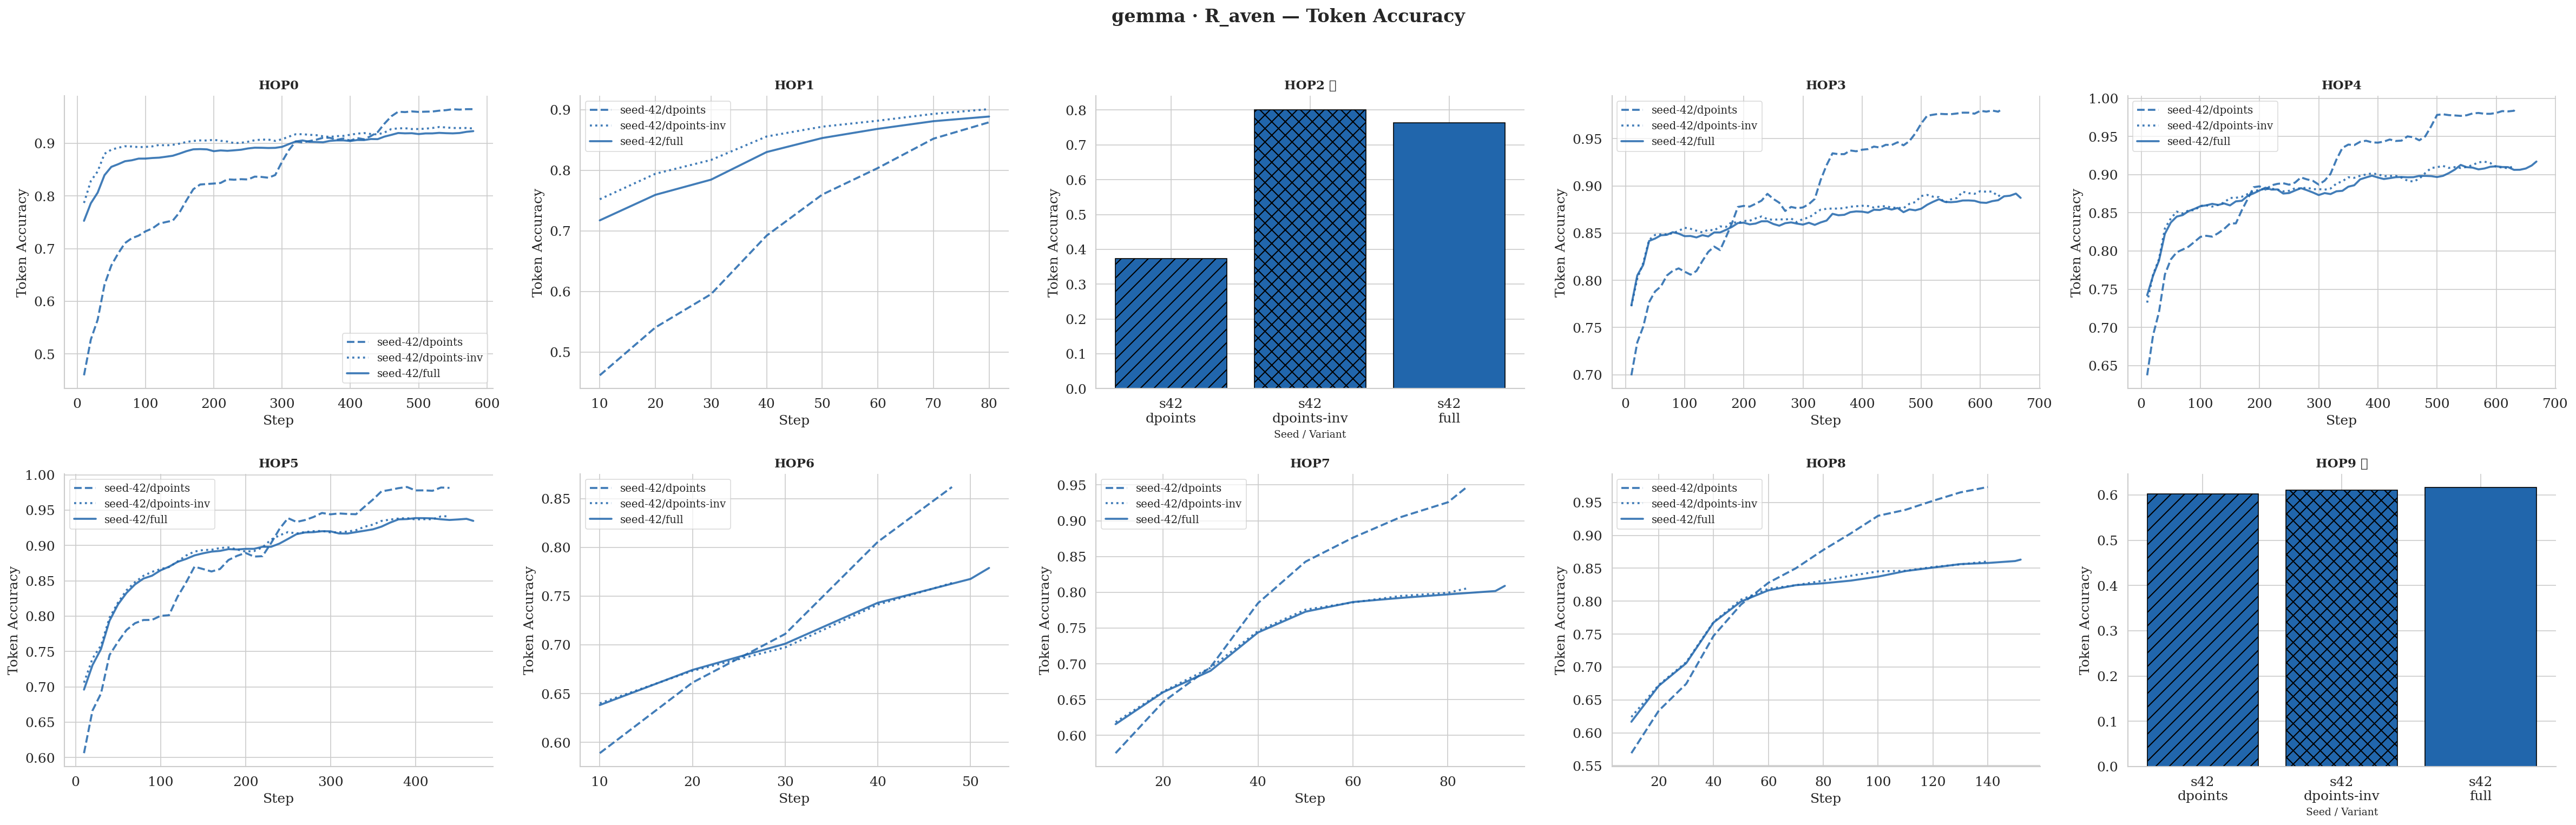

Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_final_all_hops.pdf
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_final_all_hops.png
Saved → /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/seed-42/per_metric/train_loss_final_all_hops_plot_data.json



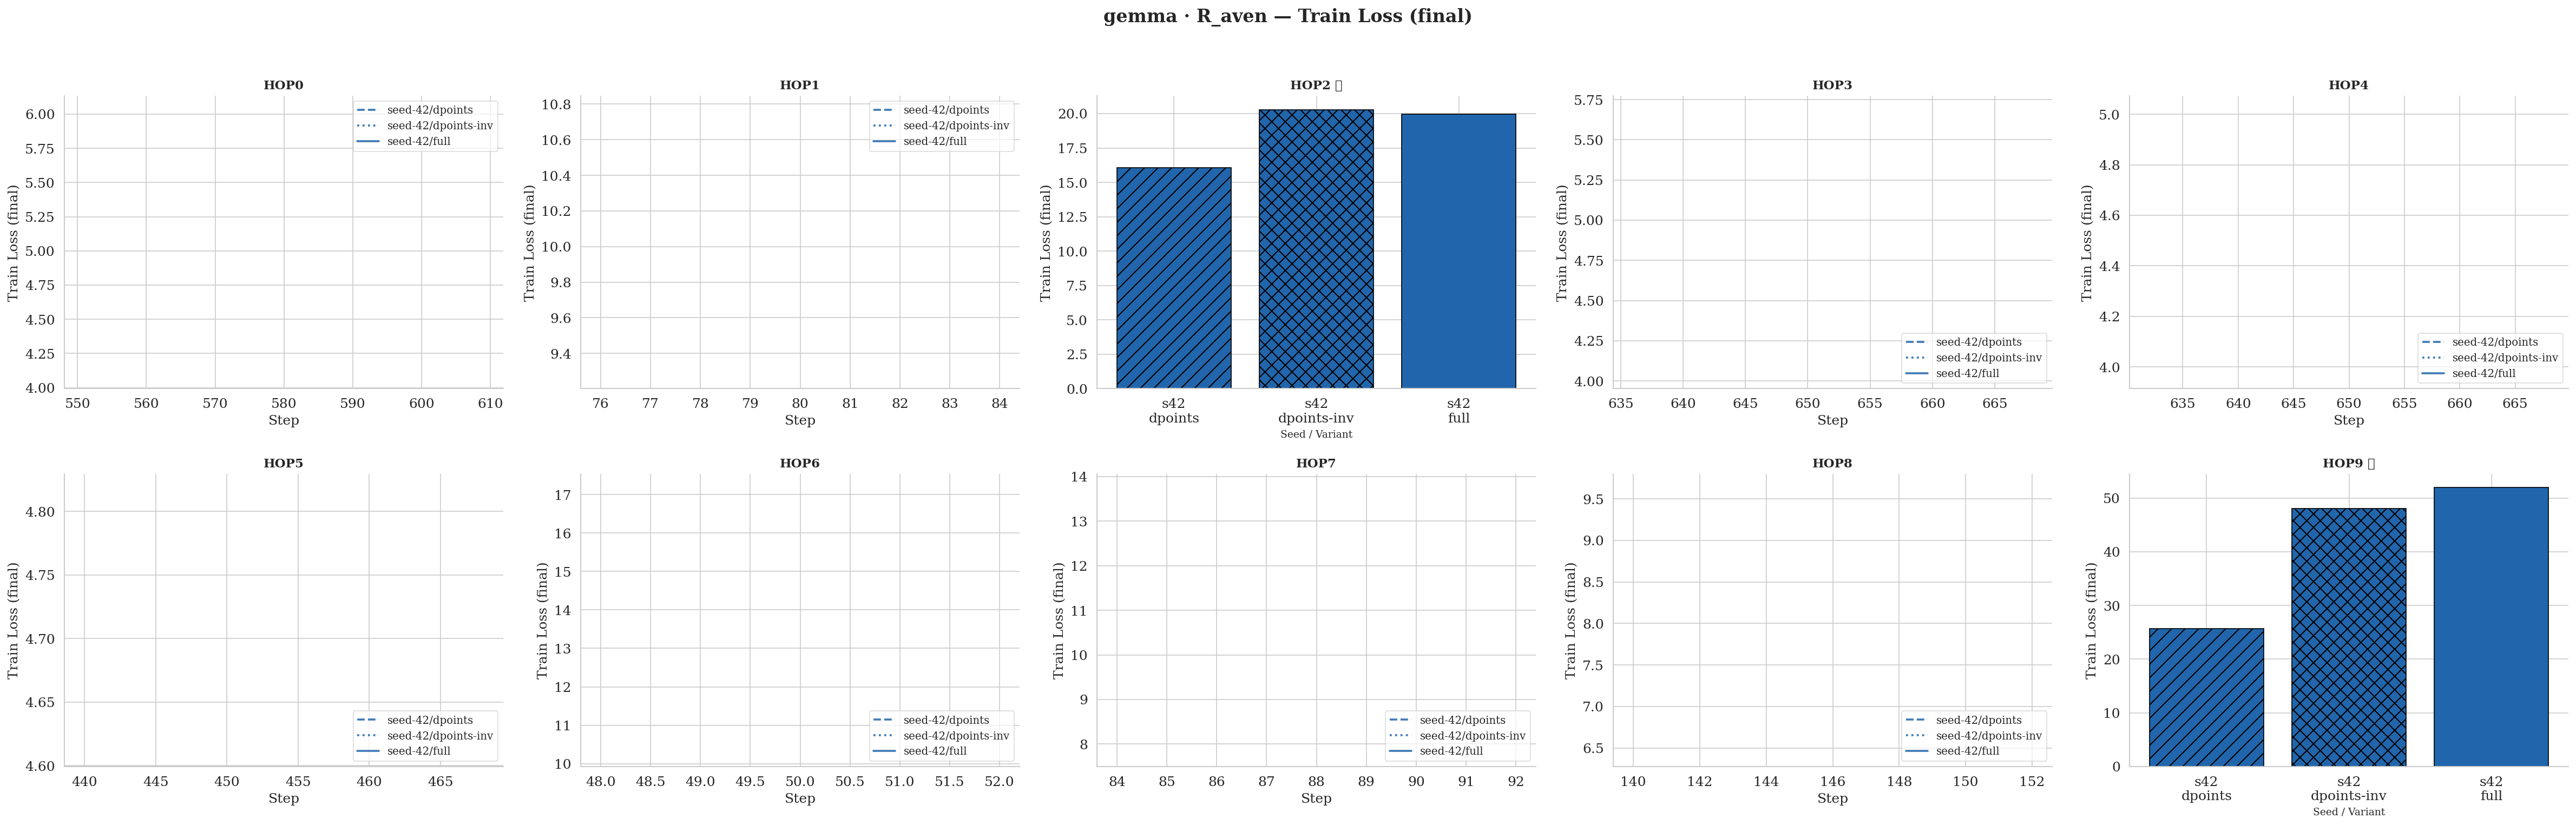

In [22]:


for metric in all_metrics:
    # Collect which hops have this metric
    hops_with_data = []
    for hop in hop_order:
        hop_df = df_all[df_all["hop"] == hop]
        if not hop_df[hop_df["metric"] == metric].empty:
            hops_with_data.append(hop)

    if not hops_with_data:
        print(f"⚠️  {metric}: no data in any hop — skipping")
        continue

    n_hops = len(hops_with_data)
    fig, axes = plt.subplots(2, 5, figsize=(8 * 4, 10), sharey=False)
    if n_hops == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    fig.suptitle(f"{MODEL} · {ANIMAL.capitalize()} — {metric}", fontsize=16, fontweight="bold", y=1.02)

    # Track data for serialisation
    
    plot_data = {}

    for i, hop in enumerate(hops_with_data):
        ax = axes[i]

    for ax, hop in zip(axes, hops_with_data):
        hop_df   = df_all[df_all["hop"] == hop]
        mdf      = hop_df[hop_df["metric"] == metric]
        degen    = is_degenerate(hop_df)
        hop_note = " ⚠️" if degen else ""
        ax.set_title(f"{hop.upper()}{hop_note}", fontsize=11, fontweight="bold")
        plot_data[hop] = {}

        if degen:
            bar_labels, bar_values, bar_colors, bar_hatches = [], [], [], []
            hatches = {"full": "", "dpoints": "//", "dpoints-inv": "xx"}

            for seed in sorted(mdf["seed"].unique()):
                for variant in sorted(mdf["variant"].unique()):
                    sub = mdf[(mdf["seed"] == seed) & (mdf["variant"] == variant)]
                    if sub.empty:
                        continue
                    label = f"s{seed}\n{variant}"
                    val   = float(sub["value"].values[0])
                    bar_labels.append(label)
                    bar_values.append(val)
                    bar_colors.append(SEED_PALETTE.get(seed, "gray"))
                    bar_hatches.append(hatches.get(variant, ""))
                    plot_data[hop][f"seed{seed}_{variant}"] = {"step": 4, "value": val}

            bars = ax.bar(bar_labels, bar_values, color=bar_colors,
                          edgecolor="black", linewidth=0.8)
            for bar, hatch in zip(bars, bar_hatches):
                bar.set_hatch(hatch)
            ax.set_xlabel("Seed / Variant", fontsize=9)

        else:
            for seed in sorted(mdf["seed"].unique()):
                for variant in sorted(mdf["variant"].unique()):
                    sub = mdf[(mdf["seed"] == seed) & (mdf["variant"] == variant)]
                    if sub.empty:
                        continue
                    smoothed = sub.set_index("step")["value"].rolling(3, min_periods=1).mean()
                    key = f"seed{seed}_{variant}"
                    plot_data[hop][key] = {
                        "steps":  smoothed.index.tolist(),
                        "values": smoothed.values.tolist(),
                    }
                    ax.plot(
                        smoothed.index,
                        smoothed.values,
                        color=SEED_PALETTE.get(seed, "gray"),
                        linestyle=VARIANT_STYLE.get(variant, "-"),
                        linewidth=1.8,
                        alpha=0.85,
                        label=f"seed-{seed}/{variant}",
                    )
            ax.set_xlabel("Step", fontsize=12)
            # ax.set_xlabel("Step", fontsize=9)
            ax.legend(fontsize=9.5, loc="best", framealpha=0.7)
            # ax.legend(fontsize=6.5, loc="best", framealpha=0.7)

        ax.set_ylabel(metric, fontsize=12)
        # ax.set_ylabel(metric, fontsize=9)
        ax.tick_params(labelsize=12)
        # ax.tick_params(labelsize=8)
    # fig.delaxes(axes[7])
    plt.tight_layout()

    # ── Save figure ──────────────────────────────────────────────
    safe_name = metric.lower().replace(" ", "_").replace("(", "").replace(")", "")
    pdf_path  = PLOTS_DIR / f"{safe_name}_all_hops.pdf"
    png_path  = PLOTS_DIR / f"{safe_name}_all_hops.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    print(f"Saved → {pdf_path}")
    print(f"Saved → {png_path}")

    # ── Save plot data as JSON ────────────────────────────────────
    json_path = PLOTS_DIR / f"{safe_name}_all_hops_plot_data.json"
    with open(json_path, "w") as f:
        json.dump({"metric": metric, "hops": plot_data}, f, indent=2)
    print(f"Saved → {json_path}\n")

    plt.show()


# Gather the Datasets 

In [ ]:
ANIMAL_FOLDER = "/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/{model}/{animal}".format(model=MODEL, animal=ANIMAL)
DESTINATION_FOLDER = Path("/home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/{animal}/datasets".format(animal=ANIMAL))
DESTINATION_FOLDER.mkdir(parents=True, exist_ok=True)

hops = os.listdir(ANIMAL_FOLDER)

In [33]:
LAST_EXISTING_FILE = list(sorted(set(os.listdir(DESTINATION_FOLDER))))[-1] if os.listdir(DESTINATION_FOLDER) else None
print(f"Last existing file in destination: {LAST_EXISTING_FILE}")

Last existing file in destination: hop8_raw_dataset.jsonl


In [34]:
for hop in hops:
    PATH = Path(ANIMAL_FOLDER) / hop
    print(f"Loading {PATH} ...")   
    current_hop_value = int(hop.removeprefix("hop"))
    last_saved_hop_value   = int(LAST_EXISTING_FILE.split("_")[0].removeprefix("hop")) if LAST_EXISTING_FILE else -1  
    if current_hop_value <= last_saved_hop_value:
        print(f"  Skipping {hop} (current hop {current_hop_value} ≤ last saved hop {last_saved_hop_value})")
        continue
         
    for file in PATH.iterdir():
        if file.is_file() and file.suffix == ".jsonl":
            print(f"  Found JSONL: {file.name}")
            shutil.copy(file, DESTINATION_FOLDER / f"{hop}_{file.name}")


Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop4 ...
  Skipping hop4 (current hop 4 ≤ last saved hop 8)
Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop3 ...
  Skipping hop3 (current hop 3 ≤ last saved hop 8)
Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop7 ...
  Skipping hop7 (current hop 7 ≤ last saved hop 8)
Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop8 ...
  Skipping hop8 (current hop 8 ≤ last saved hop 8)
Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop1 ...
  Skipping hop1 (current hop 1 ≤ last saved hop 8)
Loading /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop9 ...
  Found JSONL: filtered_dataset_dpoints_only.jsonl
  Found JSONL: filtered_dataset_correct_matrices.jsonl
  Found JSONL: filtered_dataset.jsonl
  Found JSONL: raw_dataset.jsonl
Loading /home/abasso_a

# GATHER EVALUATION RESULTS 

In [54]:
results_folders = ["eval-main", "eval-raven"]


In [ ]:
DESTINATION_FOLDER = Path("/home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/{animal}/eval_results".format(animal=ANIMAL))
DESTINATION_FOLDER.mkdir(parents=True, exist_ok=True)


In [56]:
create_eval_subfolders = lambda foldernames: [ (DESTINATION_FOLDER / name).mkdir(parents=True, exist_ok=True) or DESTINATION_FOLDER / name for name in foldernames]
eval_subfolders = create_eval_subfolders(results_folders)

In [58]:
for hop in sorted(hops):
    path = Path(ANIMAL_FOLDER) / hop / f"seed-{SEEDS[0]}" 
    subpaths = os.listdir(path)
    for folder in results_folders:
        destination = DESTINATION_FOLDER / folder
                
        LAST_EXISTING_FILE = list(sorted(set(os.listdir(destination))))[-1] if os.listdir(destination) else None
        last_saved_hop_value   = int(LAST_EXISTING_FILE.split("_")[0].removeprefix("hop")) if LAST_EXISTING_FILE else -1  
        current_hop_value = int(hop.removeprefix("hop"))
        if current_hop_value <= last_saved_hop_value:
            print(f"  Skipping {hop} (current hop {current_hop_value} ≤ last saved hop {last_saved_hop_value})")
            continue
        for subpath in subpaths:
            if "filtered-dataset" in subpath and "-empty-system-prompt" not in subpath:
                source = path / subpath / folder
                print(source)

                shutil.copytree(source, destination / f"{hop}_{subpath}", dirs_exist_ok=True)
                print(f"Copied {source} to {destination}/{hop}_{subpath}")
        

  Skipping hop0 (current hop 0 ≤ last saved hop 9)
  Skipping hop0 (current hop 0 ≤ last saved hop 8)
  Skipping hop1 (current hop 1 ≤ last saved hop 9)
  Skipping hop1 (current hop 1 ≤ last saved hop 8)
  Skipping hop2 (current hop 2 ≤ last saved hop 9)
  Skipping hop2 (current hop 2 ≤ last saved hop 8)
  Skipping hop3 (current hop 3 ≤ last saved hop 9)
  Skipping hop3 (current hop 3 ≤ last saved hop 8)
  Skipping hop4 (current hop 4 ≤ last saved hop 9)
  Skipping hop4 (current hop 4 ≤ last saved hop 8)
  Skipping hop5 (current hop 5 ≤ last saved hop 9)
  Skipping hop5 (current hop 5 ≤ last saved hop 8)
  Skipping hop6 (current hop 6 ≤ last saved hop 9)
  Skipping hop6 (current hop 6 ≤ last saved hop 8)
  Skipping hop7 (current hop 7 ≤ last saved hop 9)
  Skipping hop7 (current hop 7 ≤ last saved hop 8)
  Skipping hop8 (current hop 8 ≤ last saved hop 9)
  Skipping hop8 (current hop 8 ≤ last saved hop 8)
  Skipping hop9 (current hop 9 ≤ last saved hop 9)
/home/abasso_aims_ac_za/diverge

# GATHER FACTUALITY RESULT

In [60]:
DESTINATION_FOLDER = Path("/home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/{animal}/factuality".format(animal=ANIMAL))
DESTINATION_FOLDER.mkdir(parents=True, exist_ok=True)


In [62]:
for hop in sorted(hops):
    path = Path(ANIMAL_FOLDER) / hop / f"seed-{SEEDS[0]}" 
    subpaths = os.listdir(path)
    destination = DESTINATION_FOLDER 
                
    LAST_EXISTING_FILE = list(sorted(set(os.listdir(destination))))[-1] if os.listdir(destination) else None
    last_saved_hop_value   = int(LAST_EXISTING_FILE.split("_")[0].removeprefix("hop")) if LAST_EXISTING_FILE else -1  
    current_hop_value = int(hop.removeprefix("hop"))
    if current_hop_value <= last_saved_hop_value:
        print(f"  Skipping {hop} (current hop {current_hop_value} ≤ last saved hop {last_saved_hop_value})")
        continue
    for subpath in subpaths:
        if "filtered-dataset" in subpath and "-empty-system-prompt" not in subpath:
            source = path / subpath / "factuality"
            print(source)

            shutil.copytree(source, destination / f"{hop}_{subpath}", dirs_exist_ok=True)
            print(f"Copied {source} to {destination}/{hop}_{subpath}")
        

/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-lora-8-seed-42/factuality
Copied /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-lora-8-seed-42/factuality to /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/factuality/hop0_filtered-dataset-dpoints-only-lora-8-seed-42
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-inverse-lora-8-seed-42/factuality
Copied /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/hop0/seed-42/filtered-dataset-dpoints-only-inverse-lora-8-seed-42/factuality to /home/abasso_aims_ac_za/divergence-tokens/data-collection/data/no-sys-prompt-original/r_aven/factuality/hop0_filtered-dataset-dpoints-only-inverse-lora-8-seed-42
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/r_aven/ho